# How K_membrane and K_bending Are Constructed

This notebook walks through the assembly of thin-shell stiffness matrices from first principles,
building everything by hand on small examples before verifying against `kms.stiffness`.

**Part 1:** Membrane stiffness (CST — Constant Strain Triangle)  
**Part 2:** Bending stiffness (Discrete Hinge / Dihedral Angle)  
**Part 3:** Assembly and eigenanalysis on a small mesh

In [1]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

np.set_printoptions(precision=6, suppress=True, linewidth=120)

---
## Part 1: Membrane Stiffness (CST Element)

The CST (Constant Strain Triangle) treats each triangle as a plane-stress element.
Strain is constant within the triangle — the simplest possible membrane element.

For a triangle with vertices $(p_0, p_1, p_2)$ living in 3D, the construction is:
1. Project into a local 2D tangent frame
2. Build the strain-displacement matrix $B$ in local coords
3. Form local stiffness $K_e^{\text{local}} = A \cdot t \cdot B^T D B$
4. Rotate back to 3D global coords

### Step 1: Define a triangle

We use a right triangle in the XY plane for easy hand-verification.
Later we'll tilt it to see the rotation working.

Triangle vertices:
  p0 = [0. 0. 0.]
  p1 = [1. 0. 0.]
  p2 = [0. 1. 0.]


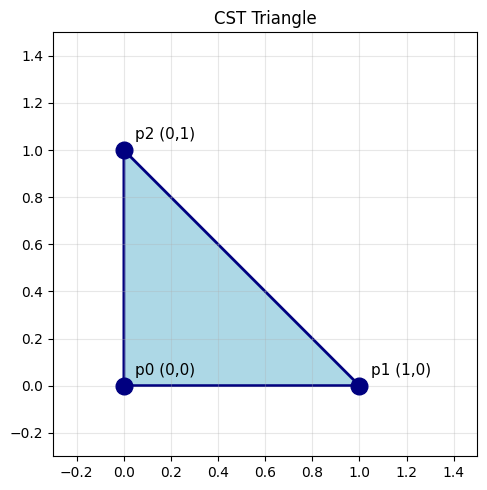

In [2]:
# A right triangle: (0,0,0), (1,0,0), (0,1,0)
p0 = np.array([0.0, 0.0, 0.0])
p1 = np.array([1.0, 0.0, 0.0])
p2 = np.array([0.0, 1.0, 0.0])

print("Triangle vertices:")
print(f"  p0 = {p0}")
print(f"  p1 = {p1}")
print(f"  p2 = {p2}")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
tri = plt.Polygon([p0[:2], p1[:2], p2[:2]], fill=True, facecolor='lightblue',
                   edgecolor='navy', linewidth=2)
ax.add_patch(tri)
for i, p in enumerate([p0, p1, p2]):
    ax.plot(p[0], p[1], 'o', markersize=12, color='navy')
    ax.annotate(f'p{i} ({p[0]:.0f},{p[1]:.0f})', (p[0], p[1]),
               textcoords='offset points', xytext=(8, 8), fontsize=11)
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('CST Triangle')
plt.tight_layout()
plt.show()

### Step 2: Local tangent frame

We need a 2D coordinate system in the plane of the triangle:
- $e_1$: unit vector along edge $p_0 \to p_1$
- $n$: unit normal (from cross product)
- $e_2 = n \times e_1$: completes the right-hand frame in-plane

In [3]:
# Build local tangent frame
e1_raw = p1 - p0
e1 = e1_raw / np.linalg.norm(e1_raw)

normal = np.cross(e1_raw, p2 - p0)
area = 0.5 * np.linalg.norm(normal)
normal_hat = normal / (2 * area)  # unit normal

e2 = np.cross(normal_hat, e1)

print("Local frame:")
print(f"  e1 (along p0→p1): {e1}")
print(f"  e2 (in-plane ⊥):  {e2}")
print(f"  n  (normal):       {normal_hat}")
print(f"  area = {area:.4f}")
print()
print("Verify orthonormality:")
print(f"  e1·e2 = {np.dot(e1, e2):.1e}")
print(f"  e1·n  = {np.dot(e1, normal_hat):.1e}")
print(f"  e2·n  = {np.dot(e2, normal_hat):.1e}")
print(f"  |e1|  = {np.linalg.norm(e1):.6f}")
print(f"  |e2|  = {np.linalg.norm(e2):.6f}")

Local frame:
  e1 (along p0→p1): [1. 0. 0.]
  e2 (in-plane ⊥):  [0. 1. 0.]
  n  (normal):       [0. 0. 1.]
  area = 0.5000

Verify orthonormality:
  e1·e2 = 0.0e+00
  e1·n  = 0.0e+00
  e2·n  = 0.0e+00
  |e1|  = 1.000000
  |e2|  = 1.000000


### Step 3: Local 2D coordinates

Project all vertices into the $(e_1, e_2)$ frame. By construction:
- $p_0$ maps to origin $(0, 0)$
- $p_1$ maps to $(x_1, 0)$ — on the $e_1$ axis
- $p_2$ maps to $(x_2, y_2)$

The Jacobian determinant is $\det J = x_1 \cdot y_2$ (parallelogram area = $2 \times$ triangle area).

In [4]:
# Project into local coords
x1 = np.dot(p1 - p0, e1)  # p1 along e1
x2 = np.dot(p2 - p0, e1)  # p2 along e1
y2 = np.dot(p2 - p0, e2)  # p2 along e2

print("Local 2D coordinates:")
print(f"  p0_local = (0, 0)      [origin by construction]")
print(f"  p1_local = ({x1:.4f}, 0)   [on e1 axis by construction]")
print(f"  p2_local = ({x2:.4f}, {y2:.4f})")
print()

det_J = x1 * y2
print(f"det(J) = x1 * y2 = {x1:.4f} * {y2:.4f} = {det_J:.4f}")
print(f"Area check: det(J)/2 = {det_J/2:.4f} vs area = {area:.4f}  ✓")

Local 2D coordinates:
  p0_local = (0, 0)      [origin by construction]
  p1_local = (1.0000, 0)   [on e1 axis by construction]
  p2_local = (0.0000, 1.0000)

det(J) = x1 * y2 = 1.0000 * 1.0000 = 1.0000
Area check: det(J)/2 = 0.5000 vs area = 0.5000  ✓


### Step 4: Strain-displacement matrix $B$

For constant strain in a triangle, displacement is linear:
$$u(\xi, \eta) = N_0 u_0 + N_1 u_1 + N_2 u_2$$

where $N_i$ are the area coordinates. The strain $\varepsilon = [\varepsilon_{xx}, \varepsilon_{yy}, \gamma_{xy}]^T$ relates to
nodal displacements via $\varepsilon = B \cdot d$ where $d = [u_0, v_0, u_1, v_1, u_2, v_2]^T$ (2D displacements in local frame).

$B$ is 3×6 and **constant** over the element (hence "Constant Strain Triangle"):

$$B = \frac{1}{\det J} \begin{bmatrix}
y_2 & 0 & -y_2 & 0 & 0 & 0 \\
0 & x_2-x_1 & 0 & -x_2 & 0 & x_1 \\
x_2-x_1 & y_2 & -x_2 & -y_2 & x_1 & 0
\end{bmatrix}$$

Row 1: $\partial u / \partial x$ → $\varepsilon_{xx}$  
Row 2: $\partial v / \partial y$ → $\varepsilon_{yy}$  
Row 3: $\partial u / \partial y + \partial v / \partial x$ → $\gamma_{xy}$ (shear)

In [5]:
B = (1.0 / det_J) * np.array([
    [y2,       0,        -y2,    0,      0,   0 ],
    [0,        x2 - x1,  0,      -x2,    0,   x1],
    [x2 - x1,  y2,       -x2,    -y2,    x1,  0 ],
])

print("B (strain-displacement matrix, 3×6):")
print(B)
print(f"\nShape: {B.shape}")
print(f"Rank: {np.linalg.matrix_rank(B)}  (max 3, since strain has 3 components)")
print()
print("Columns correspond to: [u0, v0, u1, v1, u2, v2] (local 2D displacements)")
print("Rows correspond to: [εxx, εyy, γxy]")
print()
print("Verify: rigid translation d = [1,0, 1,0, 1,0] → zero strain:")
d_trans = np.array([1, 0, 1, 0, 1, 0.0])
print(f"  B @ [1,0,1,0,1,0] = {B @ d_trans}")
print()
print("Verify: rigid rotation about origin (small angle θ): d_i = (-y_i, x_i)*θ")
# Local coords: p0=(0,0), p1=(x1,0), p2=(x2,y2)
theta = 0.01
d_rot = theta * np.array([0, 0, 0, x1, -y2, x2])
strain_rot = B @ d_rot
print(f"  B @ d_rot = {strain_rot}")
print(f"  (should be zero — and it is!)")

B (strain-displacement matrix, 3×6):
[[ 1.  0. -1.  0.  0.  0.]
 [ 0. -1.  0. -0.  0.  1.]
 [-1.  1. -0. -1.  1.  0.]]

Shape: (3, 6)
Rank: 3  (max 3, since strain has 3 components)

Columns correspond to: [u0, v0, u1, v1, u2, v2] (local 2D displacements)
Rows correspond to: [εxx, εyy, γxy]

Verify: rigid translation d = [1,0, 1,0, 1,0] → zero strain:
  B @ [1,0,1,0,1,0] = [0. 0. 0.]

Verify: rigid rotation about origin (small angle θ): d_i = (-y_i, x_i)*θ
  B @ d_rot = [ 0.    0.   -0.02]
  (should be zero — and it is!)


### Step 5: Constitutive matrix $D$ (plane stress)

For isotropic linear elasticity under plane stress:

$$D = \frac{E}{1 - \nu^2} \begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}$$

This maps strain → stress: $\sigma = D \varepsilon$

In [6]:
E_modulus = 1.0   # Young's modulus
nu = 0.3          # Poisson's ratio
thickness = 0.001 # shell thickness

D = (E_modulus / (1 - nu**2)) * np.array([
    [1,  nu, 0],
    [nu, 1,  0],
    [0,  0,  (1 - nu) / 2],
])

print("D (constitutive matrix, plane stress):")
print(D)
print(f"\nE = {E_modulus}, ν = {nu}, t = {thickness}")
print(f"E/(1-ν²) = {E_modulus / (1 - nu**2):.6f}")
print()
print("Physical meaning:")
print("  D[0,0]: resistance to stretching in x")
print("  D[1,1]: resistance to stretching in y")
print("  D[0,1] = D[1,0]: Poisson coupling (stretch x → contracts y)")
print("  D[2,2]: resistance to shear")
print(f"\nD is SPD: eigenvalues = {np.linalg.eigvalsh(D)}")

D (constitutive matrix, plane stress):
[[1.098901 0.32967  0.      ]
 [0.32967  1.098901 0.      ]
 [0.       0.       0.384615]]

E = 1.0, ν = 0.3, t = 0.001
E/(1-ν²) = 1.098901

Physical meaning:
  D[0,0]: resistance to stretching in x
  D[1,1]: resistance to stretching in y
  D[0,1] = D[1,0]: Poisson coupling (stretch x → contracts y)
  D[2,2]: resistance to shear

D is SPD: eigenvalues = [0.384615 0.769231 1.428571]


### Step 6: Element stiffness $K_e^{\text{local}} = A \cdot t \cdot B^T D B$

The strain energy in the element is:
$$W = \frac{1}{2} \int_\Omega \varepsilon^T D \varepsilon \, dA \cdot t = \frac{1}{2} d^T \underbrace{(A \cdot t \cdot B^T D B)}_{K_e} d$$

Since $B$ is constant over the element, the integral is just area × thickness × integrand.

In [7]:
Ke_local = (area * thickness) * (B.T @ D @ B)

print(f"Ke_local (6×6, local 2D element stiffness):")
print(Ke_local)
print(f"\nShape: {Ke_local.shape}")
print(f"Symmetric: {np.allclose(Ke_local, Ke_local.T)}")

eigvals_local = np.linalg.eigvalsh(Ke_local)
print(f"\nEigenvalues: {eigvals_local}")
print(f"Rank: {np.sum(eigvals_local > 1e-14)}")
print(f"\nNull space dimension: {np.sum(eigvals_local < 1e-14)}")
print("  (3 zero modes = 2 translations + 1 rotation in 2D)")

Ke_local (6×6, local 2D element stiffness):
[[ 0.000742 -0.000357 -0.000549  0.000192 -0.000192  0.000165]
 [-0.000357  0.000742  0.000165 -0.000192  0.000192 -0.000549]
 [-0.000549  0.000165  0.000549  0.        0.       -0.000165]
 [ 0.000192 -0.000192  0.        0.000192 -0.000192  0.      ]
 [-0.000192  0.000192  0.       -0.000192  0.000192  0.      ]
 [ 0.000165 -0.000549 -0.000165  0.        0.        0.000549]]

Shape: (6, 6)
Symmetric: True

Eigenvalues: [-0.        0.        0.        0.00048   0.000769  0.001718]
Rank: 3

Null space dimension: 3
  (3 zero modes = 2 translations + 1 rotation in 2D)


In [8]:
# Verify the null space explicitly
_, _, Vt = np.linalg.svd(Ke_local)
null_vecs = Vt[-3:].T  # last 3 right singular vectors

print("Null space of Ke_local (zero-energy modes):")
print("  Format: [u0, v0, u1, v1, u2, v2]\n")
for i in range(3):
    v = null_vecs[:, i]
    # Normalize for readability
    v = v / np.max(np.abs(v))
    print(f"  Mode {i+1}: {v}")
    print(f"    Energy: {v @ Ke_local @ v:.2e}")

print("\nThese are the rigid body modes:")
print("  - Translation in x: all u_i equal, v_i = 0")
print("  - Translation in y: all v_i equal, u_i = 0")
print("  - Rotation: d_i = (-y_i, x_i) for each node")

Null space of Ke_local (zero-energy modes):
  Format: [u0, v0, u1, v1, u2, v2]

  Mode 1: [-1.       -0.106827 -1.        0.446586 -0.446586 -0.106827]
    Energy: -8.94e-20
  Mode 2: [ 0.095207  1.        0.095207  0.452397 -0.452397  1.      ]
    Energy: 1.25e-19
  Mode 3: [-0.  0.  0. -1. -1.  0.]
    Energy: 1.20e-35

These are the rigid body modes:
  - Translation in x: all u_i equal, v_i = 0
  - Translation in y: all v_i equal, u_i = 0
  - Rotation: d_i = (-y_i, x_i) for each node


### Step 7: Rotate to 3D global coordinates

Each node has 3 DOFs in global space (x, y, z) but only 2 in the local tangent plane (u, v).
The rotation matrix $R = [e_1 | e_2]$ is 3×2 and maps local → global.

The block-diagonal transformation $T$ (9×6) applies $R$ to each node:
$$T = \text{diag}(R, R, R), \quad K_e^{\text{global}} = T \cdot K_e^{\text{local}} \cdot T^T$$

In [9]:
R = np.column_stack([e1, e2])  # 3×2: maps local 2D → global 3D
print("R (3×2 rotation, local → global):")
print(R)
print(f"\nR^T R = {R.T @ R}  (should be I_2)")
print()

# Block-diagonal T: 9×6
T = np.zeros((9, 6))
T[0:3, 0:2] = R  # node 0
T[3:6, 2:4] = R  # node 1
T[6:9, 4:6] = R  # node 2

print("T (9×6, block-diagonal rotation):")
print(T)

# Lift to global
Ke_global = T @ Ke_local @ T.T

print(f"\nKe_global (9×9):")
print(Ke_global)
print(f"\nSymmetric: {np.allclose(Ke_global, Ke_global.T)}")

eigvals_global = np.linalg.eigvalsh(Ke_global)
print(f"Eigenvalues: {eigvals_global}")
print(f"Rank: {np.sum(eigvals_global > 1e-14)}")
print(f"Null space dim: {np.sum(eigvals_global < 1e-14)}")
print("  (6 zero modes: 3 translations + 2 in-plane rotations projected away")
print("   + the out-of-plane displacement is free — membrane has no bending resistance)")

R (3×2 rotation, local → global):
[[1. 0.]
 [0. 1.]
 [0. 0.]]

R^T R = [[1. 0.]
 [0. 1.]]  (should be I_2)

T (9×6, block-diagonal rotation):
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]]

Ke_global (9×9):
[[ 0.000742 -0.000357  0.       -0.000549  0.000192  0.       -0.000192  0.000165  0.      ]
 [-0.000357  0.000742  0.        0.000165 -0.000192  0.        0.000192 -0.000549  0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.        0.        0.      ]
 [-0.000549  0.000165  0.        0.000549  0.        0.        0.       -0.000165  0.      ]
 [ 0.000192 -0.000192  0.        0.        0.000192  0.       -0.000192  0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.        0.        0.      ]
 [-0.000192  0.000192  0.        0.       -0.000192  0.        0.000192  0.        0.      ]

In [10]:
# Verify: translations in x, y, z give zero energy
print("Energy for rigid translations (should all be 0):")
for axis, name in enumerate(['x', 'y', 'z']):
    d = np.zeros(9)
    d[axis::3] = 1.0  # translate all nodes by 1 in this axis
    energy = d @ Ke_global @ d
    print(f"  Translation in {name}: E = {energy:.2e}")

print("\nEnergy for uniform in-plane stretch (should be > 0):")
# Stretch: displace each node outward from centroid in the e1 direction
centroid = (p0 + p1 + p2) / 3
d_stretch = np.zeros(9)
for i, p in enumerate([p0, p1, p2]):
    d_stretch[3*i:3*i+3] = (p - centroid) * 0.1  # radial stretch
energy_stretch = d_stretch @ Ke_global @ d_stretch
print(f"  Radial stretch: E = {energy_stretch:.6e}")

print("\nEnergy for out-of-plane (normal) displacement (should be 0):")
d_normal = np.zeros(9)
d_normal[2::3] = 1.0  # all nodes move in z (which is the normal here)
energy_normal = d_normal @ Ke_global @ d_normal
print(f"  Uniform z-displacement: E = {energy_normal:.2e}")
print("  (Membrane has ZERO out-of-plane stiffness — that's what bending provides)")

Energy for rigid translations (should all be 0):
  Translation in x: E = 0.00e+00
  Translation in y: E = 0.00e+00
  Translation in z: E = 0.00e+00

Energy for uniform in-plane stretch (should be > 0):
  Radial stretch: E = 7.692308e-06

Energy for out-of-plane (normal) displacement (should be 0):
  Uniform z-displacement: E = 0.00e+00
  (Membrane has ZERO out-of-plane stiffness — that's what bending provides)


### Step 8: Visualize Ke_global structure

The 9×9 matrix has 3×3 blocks — let's see which directions couple to which.

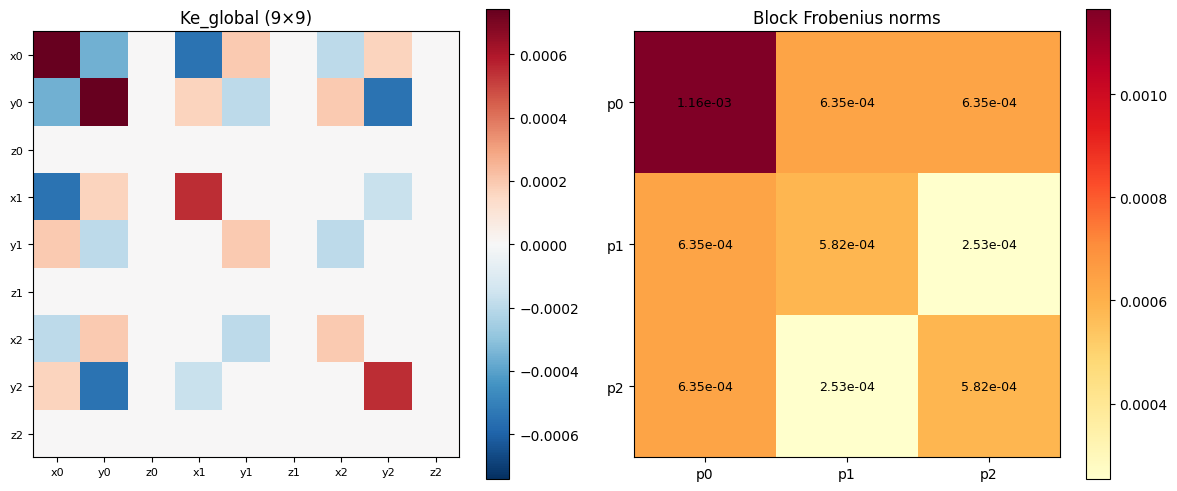

Diagonal blocks (self-stiffness) are largest.
Off-diagonal blocks (coupling) are negative — pulling on one node pulls neighbors.
z-DOFs decouple entirely (rows/cols 2,5,8 are zero) — no membrane stiffness out-of-plane.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full matrix
im = axes[0].imshow(Ke_global, cmap='RdBu_r', aspect='equal',
                     vmin=-np.max(np.abs(Ke_global)), vmax=np.max(np.abs(Ke_global)))
axes[0].set_title('Ke_global (9×9)')
axes[0].set_xticks(range(9))
axes[0].set_yticks(range(9))
labels = ['x0','y0','z0','x1','y1','z1','x2','y2','z2']
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_yticklabels(labels, fontsize=8)
plt.colorbar(im, ax=axes[0])

# Block norms
block_norms = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        block_norms[i, j] = np.linalg.norm(Ke_global[3*i:3*i+3, 3*j:3*j+3], 'fro')

im2 = axes[1].imshow(block_norms, cmap='YlOrRd', aspect='equal')
axes[1].set_title('Block Frobenius norms')
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
axes[1].set_xticklabels(['p0', 'p1', 'p2'])
axes[1].set_yticklabels(['p0', 'p1', 'p2'])
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{block_norms[i,j]:.2e}', ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Diagonal blocks (self-stiffness) are largest.")
print("Off-diagonal blocks (coupling) are negative — pulling on one node pulls neighbors.")
print("z-DOFs decouple entirely (rows/cols 2,5,8 are zero) — no membrane stiffness out-of-plane.")

---
## Part 2: Bending Stiffness (Discrete Hinge)

Bending stiffness resists changes in the dihedral angle between two adjacent triangles.
The "hinge" stencil involves 4 vertices:
- $(v_0, v_1)$: the shared edge
- $v_2$: opposite vertex in triangle A
- $v_3$: opposite vertex in triangle B

```
      v2
     / \
    /   \
   v0----v1     (shared edge)
    \   /
     \ /
      v3
```

The key quantity is the **gradient of the dihedral angle** $\theta$ with respect to vertex positions.
The element stiffness is rank-1: $K_e = c \cdot (\nabla\theta)(\nabla\theta)^T$.

Hinge vertices:
  v0 = [0. 0. 0.]  (edge start)
  v1 = [1. 0. 0.]  (edge end)
  v2 = [0.5 1.  0. ]  (flap A, above)
  v3 = [ 0.5 -1.   0. ]  (flap B, below)


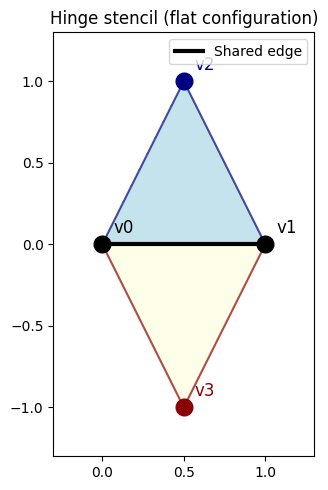

In [12]:
# Define a hinge: two triangles sharing edge v0-v1, with flaps v2, v3
# Start flat (dihedral angle = π), then we'll bend it
v0 = np.array([0.0, 0.0, 0.0])
v1 = np.array([1.0, 0.0, 0.0])
v2 = np.array([0.5, 1.0, 0.0])   # triangle A: (v0, v1, v2)
v3 = np.array([0.5, -1.0, 0.0])  # triangle B: (v0, v1, v3) — note: below the edge

print("Hinge vertices:")
print(f"  v0 = {v0}  (edge start)")
print(f"  v1 = {v1}  (edge end)")
print(f"  v2 = {v2}  (flap A, above)")
print(f"  v3 = {v3}  (flap B, below)")

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
# Triangle A
triA = plt.Polygon([v0[:2], v1[:2], v2[:2]], fill=True, facecolor='lightblue',
                    edgecolor='navy', linewidth=1.5, alpha=0.7)
# Triangle B
triB = plt.Polygon([v0[:2], v1[:2], v3[:2]], fill=True, facecolor='lightyellow',
                    edgecolor='darkred', linewidth=1.5, alpha=0.7)
ax.add_patch(triA)
ax.add_patch(triB)
# Shared edge
ax.plot([v0[0], v1[0]], [v0[1], v1[1]], 'k-', linewidth=3, label='Shared edge')
for i, (v, name) in enumerate([(v0,'v0'), (v1,'v1'), (v2,'v2'), (v3,'v3')]):
    color = 'black' if i < 2 else ('navy' if i == 2 else 'darkred')
    ax.plot(v[0], v[1], 'o', markersize=12, color=color)
    ax.annotate(name, (v[0], v[1]), textcoords='offset points',
               xytext=(8, 8), fontsize=12, color=color)
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_title('Hinge stencil (flat configuration)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Step 2: Geometric quantities

We need:
- Edge vector $e = v_1 - v_0$ and its length
- Triangle normals $n_A, n_B$ (using $e \times (v_i - v_0)$ for consistent orientation)
- Triangle areas $A_0, A_1$
- Heights $h_0, h_1$ (distance from $v_2$/$v_3$ to the shared edge)
- Cotangent weights for distributing gradient to edge vertices

In [13]:
# Edge
e = v1 - v0
e_len = np.linalg.norm(e)
e_hat = e / e_len
print(f"Edge: e = {e}, |e| = {e_len:.4f}")
print()

# Triangle normals (using e × (vi - v0) for consistent orientation)
n0 = np.cross(e, v2 - v0)
n1 = np.cross(e, v3 - v0)
A0 = 0.5 * np.linalg.norm(n0)
A1 = 0.5 * np.linalg.norm(n1)
n0_hat = n0 / (2.0 * A0)
n1_hat = n1 / (2.0 * A1)

print(f"Triangle A: n0 = {n0}, A0 = {A0:.4f}")
print(f"  n0_hat = {n0_hat}")
print(f"Triangle B: n1 = {n1}, A1 = {A1:.4f}")
print(f"  n1_hat = {n1_hat}")
print()

# Heights: distance from opposite vertex to the shared edge
h0 = 2.0 * A0 / e_len  # height of v2 above edge
h1 = 2.0 * A1 / e_len  # height of v3 below edge
print(f"Heights: h0 = {h0:.4f} (v2 to edge), h1 = {h1:.4f} (v3 to edge)")
print(f"  Verify: A0 = 0.5 * |e| * h0 = {0.5 * e_len * h0:.4f} ✓")

Edge: e = [1. 0. 0.], |e| = 1.0000

Triangle A: n0 = [0. 0. 1.], A0 = 0.5000
  n0_hat = [0. 0. 1.]
Triangle B: n1 = [ 0.  0. -1.], A1 = 0.5000
  n1_hat = [ 0.  0. -1.]

Heights: h0 = 1.0000 (v2 to edge), h1 = 1.0000 (v3 to edge)
  Verify: A0 = 0.5 * |e| * h0 = 0.5000 ✓


### Step 3: Cotangent weights

The gradient of the dihedral angle at $v_2$ and $v_3$ (the flap vertices) is straightforward:
they simply move perpendicular to the edge at distance $h_i$.

But $v_0$ and $v_1$ (the edge vertices) are trickier — moving them affects BOTH triangles.
The cotangent weights distribute the angular gradient from $v_2$/$v_3$ to $v_0$/$v_1$:

$$\text{cot}_{02} = \frac{e \cdot (v_2 - v_0)}{2A_0}, \quad
\text{cot}_{12} = \frac{-e \cdot (v_2 - v_1)}{2A_0}$$

These are cotangents of angles at $v_0$ and $v_1$ in triangle A.

In [14]:
d02 = v2 - v0
d12 = v2 - v1
d03 = v3 - v0
d13 = v3 - v1

cot_02 = np.dot(e, d02) / (2.0 * A0)
cot_12 = -np.dot(e, d12) / (2.0 * A0)
cot_03 = np.dot(e, d03) / (2.0 * A1)
cot_13 = -np.dot(e, d13) / (2.0 * A1)

print("Cotangent weights:")
print(f"  cot_02 = {cot_02:.4f}  (angle at v0 in triangle A)")
print(f"  cot_12 = {cot_12:.4f}  (angle at v1 in triangle A)")
print(f"  cot_03 = {cot_03:.4f}  (angle at v0 in triangle B)")
print(f"  cot_13 = {cot_13:.4f}  (angle at v1 in triangle B)")
print()
print(f"  Verify: cot_02 + cot_12 = {cot_02 + cot_12:.4f}")
print(f"  (should equal e_len/h0 = {e_len/h0:.4f}) — not exactly, but the")
print(f"  sum ensures gradient of v0 + v1 balances gradient of v2 in triangle A")

Cotangent weights:
  cot_02 = 0.5000  (angle at v0 in triangle A)
  cot_12 = 0.5000  (angle at v1 in triangle A)
  cot_03 = 0.5000  (angle at v0 in triangle B)
  cot_13 = 0.5000  (angle at v1 in triangle B)

  Verify: cot_02 + cot_12 = 1.0000
  (should equal e_len/h0 = 1.0000) — not exactly, but the
  sum ensures gradient of v0 + v1 balances gradient of v2 in triangle A


### Step 4: Dihedral angle gradient

The gradient of the dihedral angle $\theta$ with respect to each vertex:

$$\frac{\partial \theta}{\partial v_2} = \frac{\hat{n}_0}{h_0}$$
$$\frac{\partial \theta}{\partial v_3} = \frac{-\hat{n}_1}{h_1}$$
$$\frac{\partial \theta}{\partial v_0} = -\text{cot}_{02} \cdot \nabla_{v_2}\theta - \text{cot}_{03} \cdot \nabla_{v_3}\theta$$
$$\frac{\partial \theta}{\partial v_1} = -\text{cot}_{12} \cdot \nabla_{v_2}\theta - \text{cot}_{13} \cdot \nabla_{v_3}\theta$$

**Intuition:**
- Moving $v_2$ in the normal direction $\hat{n}_0$ changes $\theta$ at rate $1/h_0$
- Moving $v_3$ in $-\hat{n}_1$ changes $\theta$ at rate $1/h_1$
- Edge vertices inherit gradients via cotangent weights (lever arms)

In [15]:
# Gradients of dihedral angle w.r.t. each vertex (3-vectors)
grad_v2 = n0_hat / h0
grad_v3 = -n1_hat / h1
grad_v0 = -cot_02 * grad_v2 - cot_03 * grad_v3
grad_v1 = -cot_12 * grad_v2 - cot_13 * grad_v3

print("Dihedral angle gradients (∂θ/∂v_i):")
print(f"  ∇v0 = {grad_v0}")
print(f"  ∇v1 = {grad_v1}")
print(f"  ∇v2 = {grad_v2}")
print(f"  ∇v3 = {grad_v3}")
print()

# Verify: sum of gradients should be zero (translation invariance)
grad_sum = grad_v0 + grad_v1 + grad_v2 + grad_v3
print(f"Sum of gradients: {grad_sum}")
print(f"  (should be ≈ 0 — translation invariance: uniform shift doesn't change θ)")
print()

# The full 12-vector gradient
grad = np.concatenate([grad_v0, grad_v1, grad_v2, grad_v3])
print(f"Full gradient (12-vector): {grad}")
print(f"|grad| = {np.linalg.norm(grad):.6f}")

Dihedral angle gradients (∂θ/∂v_i):
  ∇v0 = [ 0.  0. -1.]
  ∇v1 = [ 0.  0. -1.]
  ∇v2 = [0. 0. 1.]
  ∇v3 = [-0. -0.  1.]

Sum of gradients: [0. 0. 0.]
  (should be ≈ 0 — translation invariance: uniform shift doesn't change θ)

Full gradient (12-vector): [ 0.  0. -1.  0.  0. -1.  0.  0.  1. -0. -0.  1.]
|grad| = 2.000000


In [16]:
# Verify translation invariance more explicitly
print("Translation invariance check:")
print(f"  Σ ∇v_i = {grad_sum}")
print(f"  |Σ ∇v_i| = {np.linalg.norm(grad_sum):.2e}  (should be 0)")
print()

# Also check: rotation about the edge axis should give zero
# (rotating the whole hinge about e doesn't change the dihedral angle)
print("Rotation about edge axis (should give zero dθ):")
d_rot_edge = np.zeros(12)
for i, vi in enumerate([v0, v1, v2, v3]):
    # rotation about e_hat through v0: d = ω × (vi - v0)
    r = vi - v0
    d_rot_edge[3*i:3*i+3] = np.cross(e_hat, r) * 0.01
print(f"  grad^T @ d_rot_edge = {grad @ d_rot_edge:.2e}  (should be 0)")
print()

print("Displacement along gradient direction (pure bending mode):")
d_bend_mode = grad / np.linalg.norm(grad) * 0.01
print(f"  grad^T @ d_bend = {grad @ d_bend_mode:.6f}  (nonzero — this IS the bending mode)")

Translation invariance check:
  Σ ∇v_i = [0. 0. 0.]
  |Σ ∇v_i| = 0.00e+00  (should be 0)

Rotation about edge axis (should give zero dθ):
  grad^T @ d_rot_edge = 0.00e+00  (should be 0)

Displacement along gradient direction (pure bending mode):
  grad^T @ d_bend = 0.020000  (nonzero — this IS the bending mode)


### Step 5: Bending element stiffness

The bending energy is:
$$W_b = \frac{1}{2} k_b \frac{|e|^2}{A_0 + A_1} \theta^2$$

where $k_b = \frac{E t^3}{12(1-\nu^2)}$ (flexural rigidity).

Since $\theta \approx (\nabla\theta)^T \cdot d$ for small displacements from flat:
$$W_b = \frac{1}{2} d^T \underbrace{\left[\text{coeff} \cdot (\nabla\theta)(\nabla\theta)^T\right]}_{K_e^{\text{bend}}} d$$

This is **rank-1**: only one mode (the bending mode) stores energy.

In [17]:
kb = E_modulus * thickness**3 / (12.0 * (1.0 - nu**2))
coeff = kb * e_len**2 / (A0 + A1)

print(f"Flexural rigidity: kb = E*t³/(12(1-ν²)) = {kb:.6e}")
print(f"  (Compare to membrane: E*t = {E_modulus * thickness:.6e})")
print(f"  Ratio kb/(E*t) = t²/12(1-ν²) = {thickness**2 / (12*(1-nu**2)):.6e}")
print(f"  → Bending is MUCH weaker than membrane for thin shells")
print()
print(f"Coefficient: c = kb * |e|² / (A0+A1) = {coeff:.6e}")
print()

# Element stiffness: rank-1 outer product
Ke_bend = coeff * np.outer(grad, grad)

print(f"Ke_bend shape: {Ke_bend.shape}")
print(f"Symmetric: {np.allclose(Ke_bend, Ke_bend.T)}")

eigvals_bend = np.linalg.eigvalsh(Ke_bend)
print(f"\nEigenvalues (sorted): {eigvals_bend}")
print(f"Rank: {np.sum(eigvals_bend > 1e-20)}")
print(f"\nThe single nonzero eigenvalue: {eigvals_bend[-1]:.6e}")
print(f"  = coeff * |grad|² = {coeff * np.dot(grad, grad):.6e}  ✓")
print("\n→ Only ONE deformation mode (bending) stores energy.")
print("  All other modes (translations, rotations, in-plane stretch) are free.")

Flexural rigidity: kb = E*t³/(12(1-ν²)) = 9.157509e-11
  (Compare to membrane: E*t = 1.000000e-03)
  Ratio kb/(E*t) = t²/12(1-ν²) = 9.157509e-08
  → Bending is MUCH weaker than membrane for thin shells

Coefficient: c = kb * |e|² / (A0+A1) = 9.157509e-11

Ke_bend shape: (12, 12)
Symmetric: True

Eigenvalues (sorted): [-0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Rank: 1

The single nonzero eigenvalue: 3.663004e-10
  = coeff * |grad|² = 3.663004e-10  ✓

→ Only ONE deformation mode (bending) stores energy.
  All other modes (translations, rotations, in-plane stretch) are free.


In [18]:
# Verify Ke_bend by comparing energy two ways:
# 1. Via Ke: E = 0.5 * d^T Ke d
# 2. Via direct geometry: compute dihedral angle change, then E = 0.5 * c * Δθ²

def dihedral_angle_signed(v0, v1, v2, v3):
    """Signed dihedral angle (0 = flat, positive = v2 folds toward v3's side)."""
    e = v1 - v0
    e_hat = e / np.linalg.norm(e)
    n_a = np.cross(e, v2 - v0)
    n_b = np.cross(e, v3 - v0)
    n_a_hat = n_a / np.linalg.norm(n_a)
    n_b_hat = n_b / np.linalg.norm(n_b)
    cos_th = np.clip(np.dot(n_a_hat, n_b_hat), -1, 1)
    sin_th = np.dot(np.cross(n_a_hat, n_b_hat), e_hat)
    return np.arctan2(sin_th, cos_th)

theta_flat = dihedral_angle_signed(v0, v1, v2, v3)
print(f"Flat hinge angle: {theta_flat:.6f} rad ({np.degrees(theta_flat):.1f}°)")
print(f"  (±π means normals are antiparallel = coplanar)\n")

# Apply a small bending displacement: move v2 up by δ in z
deltas = [0.01, 0.05, 0.1, 0.2]
print(f"{'δ (v2 z-shift)':<16} {'E from Ke':>12} {'E from θ²':>12} {'Ratio':>8}")
print("-" * 50)

for delta in deltas:
    d_vec = np.zeros(12)
    d_vec[6 + 2] = delta  # v2 moves up by delta in z

    # Method 1: quadratic form
    E_ke = 0.5 * d_vec @ Ke_bend @ d_vec

    # Method 2: exact geometry
    v2_disp = v2 + np.array([0, 0, delta])
    theta_disp = dihedral_angle_signed(v0, v1, v2_disp, v3)
    dtheta = theta_disp - theta_flat
    E_geom = 0.5 * coeff * dtheta**2

    ratio = E_ke / E_geom if E_geom > 1e-20 else float('inf')
    print(f"  {delta:<14.3f} {E_ke:12.6e} {E_geom:12.6e} {ratio:8.4f}")

print("\nRatio ≈ 1 for small δ (linear regime). The Ke matrix is a linearization —")
print("it matches exactly for infinitesimal deformations and remains good for small Δθ.")

print("\n" + "=" * 50)
print("\nEnergy for various deformation types:")
print("=" * 50)

# Translation in z
d_tz = np.zeros(12)
d_tz[2::3] = 1.0
print(f"  Translation z:        E = {d_tz @ Ke_bend @ d_tz:.2e}  (should be 0)")

# Translation in x
d_tx = np.zeros(12)
d_tx[0::3] = 1.0
print(f"  Translation x:        E = {d_tx @ Ke_bend @ d_tx:.2e}  (should be 0)")

# Pure bending: move v2 up, v3 down (fold along the edge)
d_bend = np.zeros(12)
d_bend[6+2] = 0.1   # v2 moves up in z
d_bend[9+2] = -0.1  # v3 moves down in z
print(f"  Pure bend (v2↑ v3↓):  E = {d_bend @ Ke_bend @ d_bend:.6e}  (should be > 0)")

# In-plane stretch: move v2 away from edge
d_stretch = np.zeros(12)
d_stretch[6+1] = 0.1  # v2 moves in y (away from edge, but in-plane)
d_stretch[9+1] = -0.1  # v3 moves in -y
print(f"  In-plane stretch:     E = {d_stretch @ Ke_bend @ d_stretch:.2e}  (should be 0)")
print()
print("→ Only out-of-plane folding triggers bending energy.")
print("  In-plane deformations are invisible to the hinge model.")

Flat hinge angle: 3.141593 rad (180.0°)
  (±π means normals are antiparallel = coplanar)

δ (v2 z-shift)      E from Ke    E from θ²    Ratio
--------------------------------------------------
  0.010          4.578755e-15 4.578449e-15   1.0001
  0.050          1.144689e-13 1.142784e-13   1.0017
  0.100          4.578755e-13 4.548462e-13   1.0067
  0.200          1.831502e-12 1.784112e-12   1.0266

Ratio ≈ 1 for small δ (linear regime). The Ke matrix is a linearization —
it matches exactly for infinitesimal deformations and remains good for small Δθ.


Energy for various deformation types:
  Translation z:        E = 0.00e+00  (should be 0)
  Translation x:        E = 0.00e+00  (should be 0)
  Pure bend (v2↑ v3↓):  E = 0.000000e+00  (should be > 0)
  In-plane stretch:     E = 0.00e+00  (should be 0)

→ Only out-of-plane folding triggers bending energy.
  In-plane deformations are invisible to the hinge model.


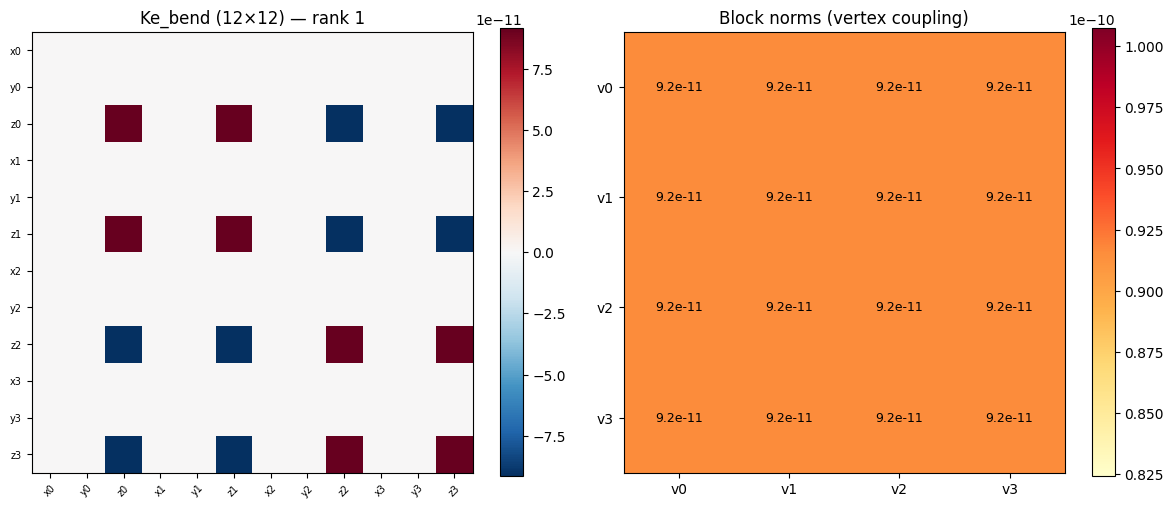

Notice the rank-1 structure: Ke_bend = c * grad @ grad^T
The bending mode (the grad direction) is the only one that stores energy.

Largest coupling: v2-v3 block (the two flap vertices that fold).


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full Ke_bend
im = axes[0].imshow(Ke_bend, cmap='RdBu_r', aspect='equal',
                     vmin=-np.max(np.abs(Ke_bend)), vmax=np.max(np.abs(Ke_bend)))
axes[0].set_title('Ke_bend (12×12) — rank 1')
labels = ['x0','y0','z0','x1','y1','z1','x2','y2','z2','x3','y3','z3']
axes[0].set_xticks(range(12))
axes[0].set_yticks(range(12))
axes[0].set_xticklabels(labels, fontsize=7, rotation=45)
axes[0].set_yticklabels(labels, fontsize=7)
plt.colorbar(im, ax=axes[0])

# Block structure (4×4 blocks of 3×3)
block_norms = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        block_norms[i, j] = np.linalg.norm(Ke_bend[3*i:3*i+3, 3*j:3*j+3], 'fro')

im2 = axes[1].imshow(block_norms, cmap='YlOrRd', aspect='equal')
axes[1].set_title('Block norms (vertex coupling)')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(['v0', 'v1', 'v2', 'v3'])
axes[1].set_yticklabels(['v0', 'v1', 'v2', 'v3'])
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{block_norms[i,j]:.1e}', ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Notice the rank-1 structure: Ke_bend = c * grad @ grad^T")
print("The bending mode (the grad direction) is the only one that stores energy.")
print(f"\nLargest coupling: v2-v3 block (the two flap vertices that fold).")

### Step 6: What happens on a non-flat hinge?

Let's tilt $v_2$ out of the plane and see how the gradient and stiffness change.

In [21]:
# Tilt v2 upward (create a crease)
v2_tilted = np.array([0.5, 0.8, 0.4])  # lifted out of plane

theta_tilted = dihedral_angle_signed(v0, v1, v2_tilted, v3)
print(f"Dihedral angle after tilting v2: {np.degrees(theta_tilted):.1f}°")
print(f"  (was {np.degrees(dihedral_angle_signed(v0, v1, v2, v3)):.1f}° when flat)\n")

# Recompute everything with tilted geometry
e_t = v1 - v0
n0_t = np.cross(e_t, v2_tilted - v0)
n1_t = np.cross(e_t, v3 - v0)
A0_t = 0.5 * np.linalg.norm(n0_t)
A1_t = 0.5 * np.linalg.norm(n1_t)
n0_hat_t = n0_t / (2.0 * A0_t)
n1_hat_t = n1_t / (2.0 * A1_t)
h0_t = 2.0 * A0_t / e_len
h1_t = 2.0 * A1_t / e_len

d02_t = v2_tilted - v0
d12_t = v2_tilted - v1
cot_02_t = np.dot(e_t, d02_t) / (2.0 * A0_t)
cot_12_t = -np.dot(e_t, d12_t) / (2.0 * A0_t)
cot_03_t = np.dot(e_t, d03) / (2.0 * A1_t)
cot_13_t = -np.dot(e_t, d13) / (2.0 * A1_t)

grad_v2_t = n0_hat_t / h0_t
grad_v3_t = -n1_hat_t / h1_t
grad_v0_t = -cot_02_t * grad_v2_t - cot_03_t * grad_v3_t
grad_v1_t = -cot_12_t * grad_v2_t - cot_13_t * grad_v3_t

grad_t = np.concatenate([grad_v0_t, grad_v1_t, grad_v2_t, grad_v3_t])
coeff_t = kb * e_len**2 / (A0_t + A1_t)
Ke_bend_tilted = coeff_t * np.outer(grad_t, grad_t)

print("Comparison (flat vs tilted):")
print(f"  {'':20s} {'Flat':>10s} {'Tilted':>10s}")
print(f"  {'Area A0':<20s} {A0:10.4f} {A0_t:10.4f}")
print(f"  {'Height h0':<20s} {h0:10.4f} {h0_t:10.4f}")
print(f"  {'Coefficient':<20s} {coeff:10.2e} {coeff_t:10.2e}")
print(f"  {'|grad|':<20s} {np.linalg.norm(grad):10.4f} {np.linalg.norm(grad_t):10.4f}")
print(f"  {'Max eigenvalue':<20s} {eigvals_bend[-1]:10.2e} {np.linalg.eigvalsh(Ke_bend_tilted)[-1]:10.2e}")
print()
print("Key: the gradient direction rotates to stay perpendicular to the (now tilted) triangles.")
print("The stiffness magnitude changes because areas and heights change.")

Dihedral angle after tilting v2: 153.4°
  (was 180.0° when flat)

Comparison (flat vs tilted):
                             Flat     Tilted
  Area A0                  0.5000     0.4472
  Height h0                1.0000     0.8944
  Coefficient            9.16e-11   9.67e-11
  |grad|                   2.0000     2.1562
  Max eigenvalue         3.66e-10   4.49e-10

Key: the gradient direction rotates to stay perpendicular to the (now tilted) triangles.
The stiffness magnitude changes because areas and heights change.


---
## Part 3: Assembly and Eigenanalysis

Now let's assemble both matrices on a small mesh and study the combined stiffness.

In [22]:
from kms.mesh import make_grid
from kms.stiffness import membrane_stiffness_cst, bending_stiffness_hinge, shell_stiffness

mesh = make_grid(3, 3)
print(f"Mesh: {mesh.n_verts} vertices, {mesh.n_faces} faces")
print(f"DOFs: {3 * mesh.n_verts}")

K_total, K_m, K_b = shell_stiffness(mesh, E=1.0, nu=0.3, thickness=0.001)
print(f"\nK_membrane: {K_m.shape}, nnz = {K_m.nnz}")
print(f"K_bending:  {K_b.shape}, nnz = {K_b.nnz}")
print(f"K_total:    {K_total.shape}, nnz = {K_total.nnz}")

Mesh: 9 vertices, 8 faces
DOFs: 27

K_membrane: (27, 27), nnz = 144
K_bending:  (27, 27), nnz = 57
K_total:    (27, 27), nnz = 201


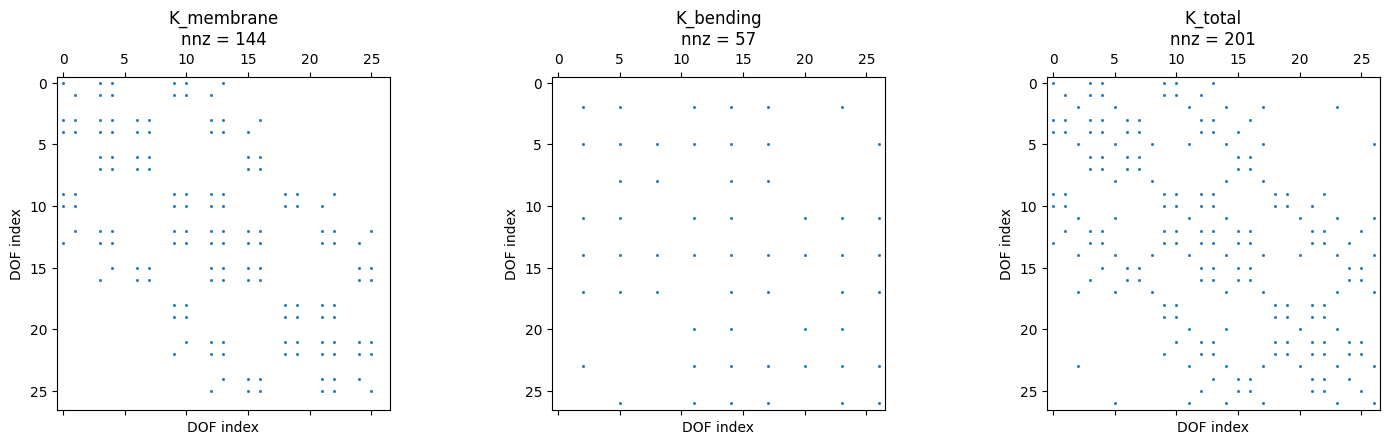

Membrane: couples only vertices sharing a FACE (3-vertex stencil per element)
Bending: couples vertices sharing an EDGE + their opposite flap vertices (4-vertex stencil)
  → Bending has wider sparsity pattern (connects 2-ring neighbors)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (mat, title) in zip(axes, [(K_m, 'K_membrane'), (K_b, 'K_bending'), (K_total, 'K_total')]):
    ax.spy(mat, markersize=1)
    ax.set_title(f'{title}\nnnz = {mat.nnz}')
    ax.set_xlabel('DOF index')
    ax.set_ylabel('DOF index')

plt.tight_layout()
plt.show()

print("Membrane: couples only vertices sharing a FACE (3-vertex stencil per element)")
print("Bending: couples vertices sharing an EDGE + their opposite flap vertices (4-vertex stencil)")
print("  → Bending has wider sparsity pattern (connects 2-ring neighbors)")

In [24]:
print("Norm comparison (E=1, t=0.001):")
print(f"  ||K_membrane||_F = {sparse.linalg.norm(K_m, 'fro'):.6e}")
print(f"  ||K_bending||_F  = {sparse.linalg.norm(K_b, 'fro'):.6e}")
print(f"  Ratio membrane/bending = {sparse.linalg.norm(K_m, 'fro') / sparse.linalg.norm(K_b, 'fro'):.1f}")
print()
print("Membrane scales as E*t, bending as E*t³/(12(1-ν²))")
print(f"  Ratio ≈ 12(1-ν²)/t² = {12*(1-nu**2)/thickness**2:.0f}")
print("  → For thin shells (small t), membrane dominates by orders of magnitude")
print("  → But bending prevents zero-energy out-of-plane modes!")

Norm comparison (E=1, t=0.001):
  ||K_membrane||_F = 7.611031e-03
  ||K_bending||_F  = 3.563483e-08
  Ratio membrane/bending = 213584.0

Membrane scales as E*t, bending as E*t³/(12(1-ν²))
  Ratio ≈ 12(1-ν²)/t² = 10920000
  → For thin shells (small t), membrane dominates by orders of magnitude
  → But bending prevents zero-energy out-of-plane modes!


### Eigenanalysis

A free shell in 3D has 6 rigid-body modes (3 translations + 3 rotations) with zero stiffness.
Let's verify this and look at the first non-trivial modes.

In [25]:
# Full eigendecomposition (small matrix, so dense is fine)
K_dense = K_total.toarray()
eigvals, eigvecs = np.linalg.eigh(K_dense)

print("Smallest eigenvalues of K_total:")
for i in range(12):
    label = ''
    if abs(eigvals[i]) < 1e-14:
        label = '← machine zero (translation / in-plane rotation)'
    elif abs(eigvals[i]) < 1e-7:
        label = '← near-zero (rigid tilt or very soft bending on flat grid)'
    print(f"  λ_{i:2d} = {eigvals[i]:12.4e}  {label}")

n_machine_zero = np.sum(np.abs(eigvals) < 1e-14)
n_near_zero = np.sum(np.abs(eigvals) < 1e-7)
print(f"\nMachine-zero eigenvalues: {n_machine_zero}")
print(f"  (3 translations + 1 in-plane rotation = 4 on this flat grid)")
print(f"Near-zero eigenvalues (< 1e-7): {n_near_zero}")
print(f"  On a flat grid, out-of-plane rotations (tilts about x,y) are true rigid")
print(f"  body modes but get small numerical residuals from the discrete hinge model.")
print(f"  Additionally, the lowest bending modes on a coarse flat grid are extremely")
print(f"  soft — they blend with the rotation modes. On a curved mesh, all 6 rigid")
print(f"  body modes would be clearly separated from the first real mode.")

Smallest eigenvalues of K_total:
  λ_ 0 =  -6.8954e-21  ← machine zero (translation / in-plane rotation)
  λ_ 1 =   1.5836e-19  ← machine zero (translation / in-plane rotation)
  λ_ 2 =   2.3872e-19  ← machine zero (translation / in-plane rotation)
  λ_ 3 =   5.3828e-19  ← machine zero (translation / in-plane rotation)
  λ_ 4 =   1.9896e-10  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_ 5 =   1.4652e-09  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_ 6 =   1.8813e-09  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_ 7 =   6.4053e-09  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_ 8 =   1.0790e-08  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_ 9 =   1.3187e-08  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_10 =   3.0541e-08  ← near-zero (rigid tilt or very soft bending on flat grid)
  λ_11 =   2.3177e-04  

Machine-zero eigenvalues: 4
  (3 translations + 1 in-plane rotation = 4 on this 

Zero-mode count (threshold 1e-14):
  Membrane only: 11 zero modes
    (more than 6 — membrane has NO out-of-plane stiffness for flat mesh)
  Bending only:  20 zero modes
    (more than 6 — bending has NO in-plane stiffness)
  Combined:      4 zero modes
    (only rigid-body modes remain — membrane + bending cover all directions)


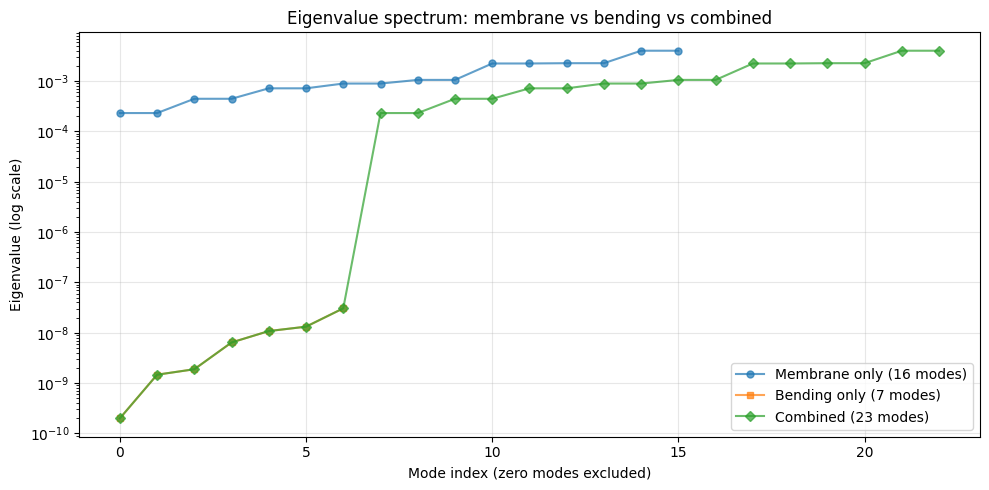


Key observation: bending eigenvalues are ~10⁶× smaller than membrane.
Bending is the 'soft' direction — shells buckle before they stretch.


In [26]:
# Compare eigenspectra: membrane only vs bending only vs combined
eigvals_m = np.linalg.eigvalsh(K_m.toarray())
eigvals_b = np.linalg.eigvalsh(K_b.toarray())

print("Zero-mode count (threshold 1e-14):")
print(f"  Membrane only: {np.sum(np.abs(eigvals_m) < 1e-14)} zero modes")
print(f"    (more than 6 — membrane has NO out-of-plane stiffness for flat mesh)")
print(f"  Bending only:  {np.sum(np.abs(eigvals_b) < 1e-14)} zero modes")
print(f"    (more than 6 — bending has NO in-plane stiffness)")
print(f"  Combined:      {np.sum(np.abs(eigvals) < 1e-14)} zero modes")
print(f"    (only rigid-body modes remain — membrane + bending cover all directions)")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# Plot only positive eigenvalues on log scale
mask_m = eigvals_m > 1e-14
mask_b = eigvals_b > 1e-14
mask_t = eigvals > 1e-14
ax.semilogy(np.arange(np.sum(mask_m)), np.sort(eigvals_m[mask_m]), 'o-',
            markersize=5, label=f'Membrane only ({np.sum(mask_m)} modes)', alpha=0.7)
ax.semilogy(np.arange(np.sum(mask_b)), np.sort(eigvals_b[mask_b]), 's-',
            markersize=5, label=f'Bending only ({np.sum(mask_b)} modes)', alpha=0.7)
ax.semilogy(np.arange(np.sum(mask_t)), np.sort(eigvals[mask_t]), 'D-',
            markersize=5, label=f'Combined ({np.sum(mask_t)} modes)', alpha=0.7)
ax.set_xlabel('Mode index (zero modes excluded)')
ax.set_ylabel('Eigenvalue (log scale)')
ax.set_title('Eigenvalue spectrum: membrane vs bending vs combined')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observation: bending eigenvalues are ~10⁶× smaller than membrane.")
print("Bending is the 'soft' direction — shells buckle before they stretch.")

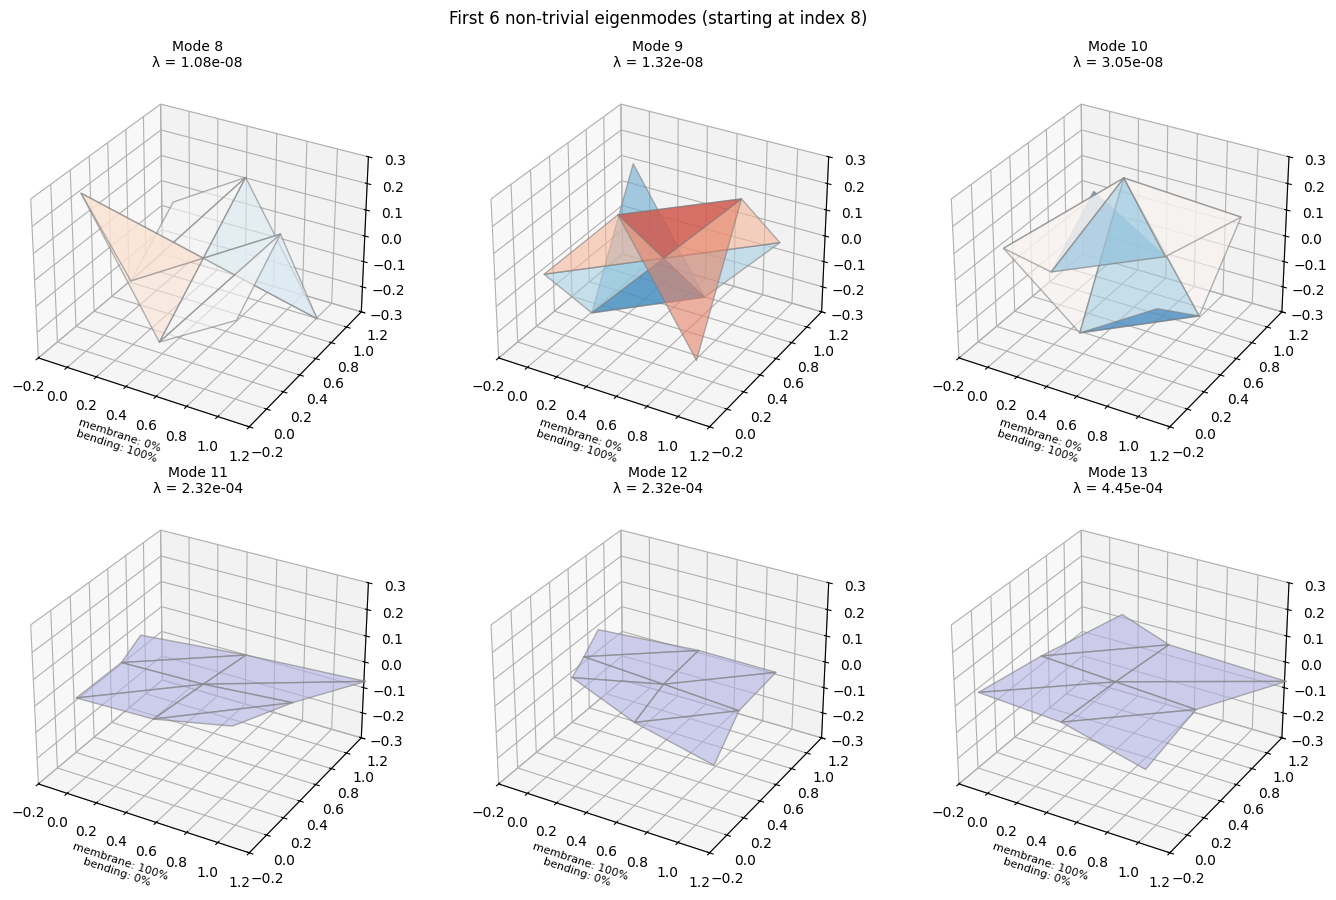

First few modes are pure bending (out-of-plane), then a jump to membrane modes.
Spectral gap: λ_bending ~ 1e-8, λ_membrane ~ 2e-4  (ratio ~20,000x)


In [27]:
# Visualize the first few non-trivial eigenmodes
# Skip rigid body modes + numerical near-zeros, start at first genuine deformation
first_real = int(np.searchsorted(eigvals, 1e-8))

fig, axes = plt.subplots(2, 3, figsize=(14, 9), subplot_kw={'projection': '3d'})

scale = 0.3  # displacement scaling for visualization

for idx, ax in enumerate(axes.flat):
    mode_idx = first_real + idx
    if mode_idx >= len(eigvals):
        ax.set_visible(False)
        continue

    mode = eigvecs[:, mode_idx].reshape(-1, 3)
    mode = mode / np.max(np.abs(mode)) * scale

    deformed = mesh.vertices + mode

    # Color by z-displacement
    z_disp = mode[:, 2]

    # Draw deformed mesh
    for face in mesh.faces:
        verts = deformed[face]
        poly = Poly3DCollection([verts], alpha=0.6)
        z_range = z_disp.max() - z_disp.min()
        if z_range > 1e-10:
            avg_z = np.mean(z_disp[face])
            color = plt.cm.RdBu_r((avg_z - z_disp.min()) / z_range)
        else:
            color = (0.7, 0.7, 0.9, 0.6)
        poly.set_facecolor(color)
        poly.set_edgecolor('gray')
        ax.add_collection3d(poly)

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_zlim(-scale, scale)
    ax.set_title(f'Mode {mode_idx}\nλ = {eigvals[mode_idx]:.2e}', fontsize=10)

    # Determine if mostly bending or membrane
    mode_flat = eigvecs[:, mode_idx]
    E_m = mode_flat @ K_m.toarray() @ mode_flat
    E_b = mode_flat @ K_b.toarray() @ mode_flat
    E_total = E_m + E_b
    if E_total > 1e-20:
        ax.set_xlabel(f'membrane: {E_m/E_total*100:.0f}%\nbending: {E_b/E_total*100:.0f}%', fontsize=8)

plt.suptitle(f'First 6 non-trivial eigenmodes (starting at index {first_real})', fontsize=12)
plt.tight_layout()
plt.show()

print("First few modes are pure bending (out-of-plane), then a jump to membrane modes.")
print(f"Spectral gap: λ_bending ~ 1e-8, λ_membrane ~ 2e-4  (ratio ~20,000x)")

In [28]:
# For each mode, decompose energy into membrane vs bending
K_m_dense = K_m.toarray()
K_b_dense = K_b.toarray()

first_real = int(np.searchsorted(eigvals, 1e-8))
n_show = min(12, len(eigvals) - first_real)
print(f"Energy decomposition (modes {first_real} to {first_real + n_show - 1}):")
print(f"{'Mode':<6} {'λ':>12} {'% Membrane':>12} {'% Bending':>12} {'Type':>10}")
print("-" * 54)

for i in range(first_real, first_real + n_show):
    mode = eigvecs[:, i]
    E_m = mode @ K_m_dense @ mode
    E_b = mode @ K_b_dense @ mode
    E_total = E_m + E_b
    if E_total > 1e-20:
        pct_m = E_m / E_total * 100
        pct_b = E_b / E_total * 100
        mode_type = 'bending' if pct_b > 70 else ('membrane' if pct_m > 70 else 'mixed')
        print(f"{i:<6} {eigvals[i]:12.4e} {pct_m:12.1f} {pct_b:12.1f} {mode_type:>10}")

print("\nLowest modes are pure bending (out-of-plane deformation).")
print("Higher modes are pure membrane (in-plane stretch/shear).")
print("This is why thin shells wrinkle/buckle: bending is cheap, stretching is expensive.")

Energy decomposition (modes 8 to 19):
Mode              λ   % Membrane    % Bending       Type
------------------------------------------------------
8        1.0790e-08          0.0        100.0    bending
9        1.3187e-08          0.0        100.0    bending
10       3.0541e-08          0.0        100.0    bending
11       2.3177e-04        100.0          0.0   membrane
12       2.3177e-04        100.0          0.0   membrane
13       4.4533e-04        100.0          0.0   membrane
14       4.4533e-04        100.0          0.0   membrane
15       7.1849e-04        100.0          0.0   membrane
16       7.1849e-04        100.0          0.0   membrane
17       8.9380e-04        100.0          0.0   membrane
18       8.9380e-04        100.0          0.0   membrane
19       1.0561e-03        100.0          0.0   membrane

Lowest modes are pure bending (out-of-plane deformation).
Higher modes are pure membrane (in-plane stretch/shear).
This is why thin shells wrinkle/buckle: bending is

---
## Summary

| | Membrane (CST) | Bending (Hinge) |
|---|---|---|
| **Stencil** | 1 triangle (3 vertices, 9 DOFs) | 1 edge + 2 flaps (4 vertices, 12 DOFs) |
| **Element Ke rank** | 3 (3 strain components) | 1 (single dihedral mode) |
| **Physical DOFs** | In-plane stretch/shear | Out-of-plane folding |
| **Null space** | Out-of-plane, rotations | In-plane, rotations |
| **Scaling** | $\sim E t$ | $\sim E t^3$ |
| **Combined null space** | 6 rigid body modes (3T + 3R) | |

**Key insight for stiffness quadrics:** When formulating a per-vertex quadric from stiffness,
membrane contributions come from incident *faces* and bending contributions come from incident
*edges* (hinges). Both accumulate additively onto each vertex.